# Lecture 10

Saved svd_geometry_boxed.pdf and .png


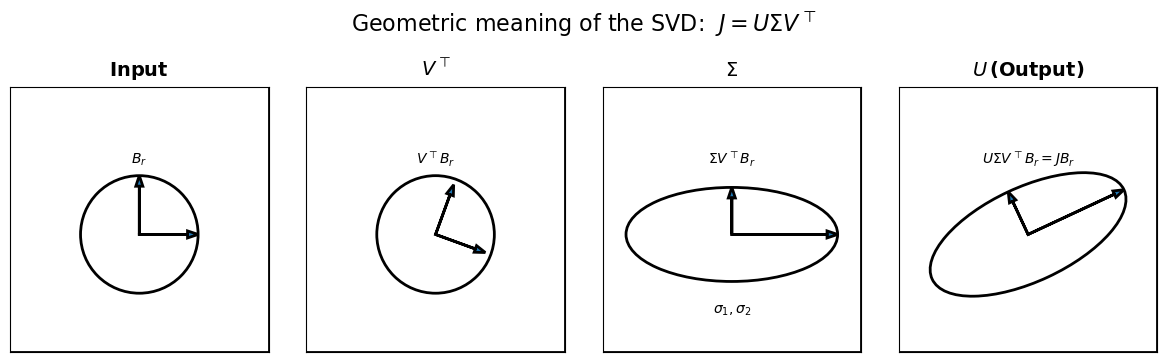

In [7]:
#!/usr/bin/env python3
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle, Rectangle

def rot(theta_deg):
    t = np.deg2rad(theta_deg)
    return np.array([[np.cos(t), -np.sin(t)],
                     [np.sin(t),  np.cos(t)]])

def draw_principal_axes(ax, sigma1, sigma2, angle_deg):
    R = rot(angle_deg)
    e1 = R @ np.array([1.0, 0.0])
    e2 = R @ np.array([0.0, 1.0])
    ax.arrow(0, 0, sigma1*e1[0], sigma1*e1[1],
             head_width=0.12, length_includes_head=True, linewidth=2)
    ax.arrow(0, 0, sigma2*e2[0], sigma2*e2[1],
             head_width=0.12, length_includes_head=True, linewidth=2)

def setup_panel(ax):
    ax.set_aspect('equal')
    ax.set_xlim(-2.2, 2.2)
    ax.set_ylim(-2.0, 2.5)
    ax.set_xticks([])
    ax.set_yticks([])
    rect = Rectangle((-2.2, -2.0), 4.4, 4.5,
                     fill=False, linewidth=1.3)
    ax.add_patch(rect)

def main():
    r = 1.0
    sigma1 = 1.8
    sigma2 = 0.8
    thetaU = 25
    thetaV = -20

    fig, axs = plt.subplots(1, 4, figsize=(12, 3.4))

    # Global title
    fig.suptitle("Geometric meaning of the SVD:  $J = U \\Sigma V^\\top$",
                 fontsize=16, y=1.05)

    titles = [r"$\mathbf{Input}$",
              r"$V^\top$",
              r"$\Sigma$",
              r"$U\,\mathbf{(Output)}$"]

    for ax, t in zip(axs, titles):
        setup_panel(ax)
        ax.set_title(t, fontsize=14, pad=8)

    # Panel 1: Input
    axs[0].add_patch(Circle((0, 0), r, fill=False, linewidth=2))
    axs[0].arrow(0, 0, r, 0,
                 head_width=0.12, length_includes_head=True, linewidth=2)
    axs[0].arrow(0, 0, 0, r,
                 head_width=0.12, length_includes_head=True, linewidth=2)
    axs[0].text(0, 1.2, r"$B_r$", ha='center')

    # Panel 2: V^T
    axs[1].add_patch(Circle((0, 0), r, fill=False, linewidth=2))
    Rv = rot(thetaV)
    axs[1].arrow(0, 0, *(0.9*Rv[:,0]),
                 head_width=0.12, length_includes_head=True, linewidth=2)
    axs[1].arrow(0, 0, *(0.9*Rv[:,1]),
                 head_width=0.12, length_includes_head=True, linewidth=2)
    axs[1].text(0, 1.2, r"$V^\top B_r$", ha='center')

    # Panel 3: Sigma
    axs[2].add_patch(Ellipse((0, 0),
                             width=2*sigma1,
                             height=2*sigma2,
                             angle=0,
                             fill=False,
                             linewidth=2))
    draw_principal_axes(axs[2], sigma1, sigma2, 0)
    axs[2].text(0, 1.2, r"$\Sigma V^\top B_r$", ha='center')
    axs[2].text(0, -1.35, r"$\sigma_1,\sigma_2$", ha='center')

    # Panel 4: U (Output)
    axs[3].add_patch(Ellipse((0, 0),
                             width=2*sigma1,
                             height=2*sigma2,
                             angle=thetaU,
                             fill=False,
                             linewidth=2))
    draw_principal_axes(axs[3], sigma1, sigma2, thetaU)
    axs[3].text(0, 1.2,
                r"$U\Sigma V^\top B_r = J B_r$",
                ha='center')

    fig.tight_layout()
    fig.savefig("svd_geometry_boxed.pdf", bbox_inches="tight")
    fig.savefig("svd_geometry_boxed.png", dpi=200, bbox_inches="tight")
    print("Saved svd_geometry_boxed.pdf and .png")

if __name__ == "__main__":
    main()


Class: n01440764
Input shape: torch.Size([1, 1, 16, 16])


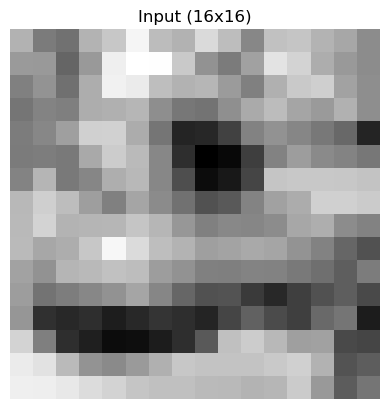


Layer-wise Jacobian statistics:
          conv1 | J shape=torch.Size([1536, 256]) | svs=256 | eff_rank=256 | smax=1.85 | smin=0.7396
          relu1 | J shape=torch.Size([1536, 256]) | svs=256 | eff_rank=256 | smax=1.213 | smin=0.3479
  conv2_stride2 | J shape=torch.Size([512, 256]) | svs=256 | eff_rank=256 | smax=0.5942 | smin=0.04837
          relu2 | J shape=torch.Size([512, 256]) | svs=256 | eff_rank=256 | smax=0.5513 | smin=0.008229
        gap_1x1 | J shape=torch.Size([8, 256]) | svs=8 | eff_rank=6 | smax=0.04582 | smin=2.14e-11


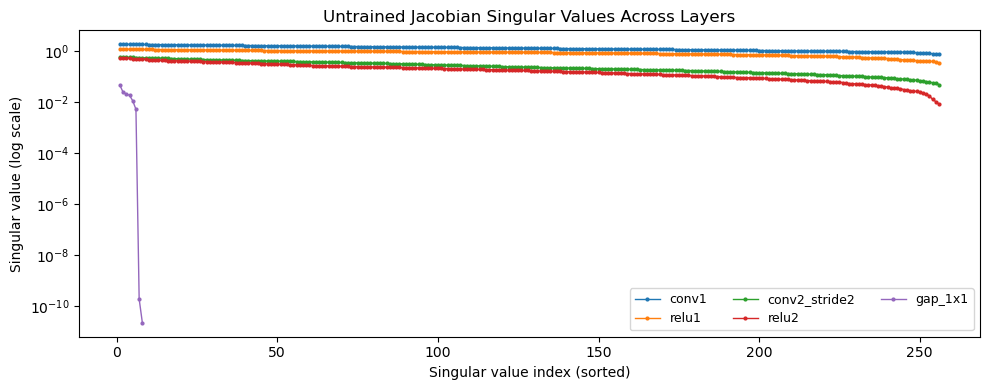

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torchvision import transforms
from torchvision.datasets import ImageFolder

# =========================
# Config
# =========================
VAL_ROOT = "../../datasets/imagenette2/val"
IMG_SIZE = 16
PICK_INDEX = 0
SV_THRESHOLD = 1e-3
device = torch.device("cpu")

torch.manual_seed(0)
np.random.seed(0)

# =========================
# Tiny CNN (UNTRAINED)
# =========================
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 3, stride=1, padding=1)
        self.relu1 = nn.ReLU(inplace=False)
        self.conv2 = nn.Conv2d(6, 8, 3, stride=2, padding=1)
        self.relu2 = nn.ReLU(inplace=False)
        self.gap = nn.AdaptiveAvgPool2d((1,1))

    def forward_with_acts(self, x):
        acts = {}
        a1 = self.conv1(x); acts["conv1"] = a1
        r1 = self.relu1(a1); acts["relu1"] = r1
        a2 = self.conv2(r1); acts["conv2_stride2"] = a2
        r2 = self.relu2(a2); acts["relu2"] = r2
        g  = self.gap(r2);  acts["gap_1x1"] = g
        return acts

model = TinyCNN().to(device).eval()

# =========================
# Load one image
# =========================
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(1),
    transforms.ToTensor()
])

dataset = ImageFolder(VAL_ROOT, transform=transform)
x, y = dataset[PICK_INDEX]
class_name = dataset.classes[y]

x = x.unsqueeze(0).to(device).requires_grad_(True)

print("Class:", class_name)
print("Input shape:", x.shape)

plt.imshow(x.detach().cpu().squeeze(), cmap="gray")
plt.title("Input (16x16)")
plt.axis("off")
plt.show()

# =========================
# Jacobian + SVD
# =========================
def flatten_act(t):
    return t.reshape(-1)

def compute_svals(model, x, layer_name):
    def layer_fn(x_in):
        acts = model.forward_with_acts(x_in)
        return flatten_act(acts[layer_name])
    J = torch.autograd.functional.jacobian(layer_fn, x, vectorize=True)
    J = J.reshape(J.shape[0], -1)
    svals = torch.linalg.svdvals(J)
    return svals, J.shape

def summarize(svals, tau):
    s = svals.detach().cpu().numpy()
    return {
        "count": len(s),
        "eff_rank": int(np.sum(s > tau)),
        "sigma_max": float(s.max()),
        "sigma_min": float(s.min())
    }

layer_order = ["conv1", "relu1", "conv2_stride2", "relu2", "gap_1x1"]
layer_svals = {}

print("\nLayer-wise Jacobian statistics:")
for name in layer_order:
    svals, shape = compute_svals(model, x, name)
    stats = summarize(svals, SV_THRESHOLD)
    layer_svals[name] = svals.detach().cpu()
    print(f"{name:>15} | J shape={shape} | "
          f"svs={stats['count']} | "
          f"eff_rank={stats['eff_rank']} | "
          f"smax={stats['sigma_max']:.4g} | "
          f"smin={stats['sigma_min']:.4g}")

# =========================
# Plot singular values
# =========================
plt.figure(figsize=(10,4))
for name in layer_order:
    s = np.sort(layer_svals[name].numpy())[::-1]
    plt.plot(range(1, len(s)+1), s, marker='o', markersize=2, linewidth=1, label=name)

plt.yscale("log")
plt.xlabel("Singular value index (sorted)")
plt.ylabel("Singular value (log scale)")
plt.title("Untrained Jacobian Singular Values Across Layers")
plt.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.savefig("untrained_jacobian_svals.pdf", bbox_inches="tight")
plt.show()

Device: cuda
Probe val index: 0 | class: n01440764
Probe input shape: (1, 1, 16, 16)


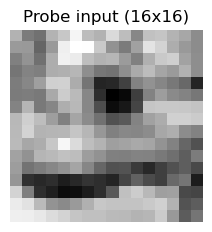


UNTRAINED layer-wise Jacobian stats:
          conv1 | J shape=torch.Size([1536, 256]) | svs=256 | eff_rank=256 | smax=1.85 | smin=0.7397
          relu1 | J shape=torch.Size([1536, 256]) | svs=256 | eff_rank=256 | smax=1.213 | smin=0.3479
  conv2_stride2 | J shape=torch.Size([512, 256]) | svs=256 | eff_rank=256 | smax=0.5942 | smin=0.04837
          relu2 | J shape=torch.Size([512, 256]) | svs=256 | eff_rank=256 | smax=0.5513 | smin=0.00823
        gap_1x1 | J shape=torch.Size([8, 256]) | svs=8 | eff_rank=6 | smax=0.04582 | smin=0

Training...
Epoch 01/100 | train_loss=2.3052 | val_acc@50batches=0.187
Epoch 02/100 | train_loss=2.2668 | val_acc@50batches=0.174
Epoch 03/100 | train_loss=2.2125 | val_acc@50batches=0.185
Epoch 04/100 | train_loss=2.1715 | val_acc@50batches=0.195
Epoch 05/100 | train_loss=2.1479 | val_acc@50batches=0.206
Epoch 06/100 | train_loss=2.1365 | val_acc@50batches=0.221
Epoch 07/100 | train_loss=2.1328 | val_acc@50batches=0.221
Epoch 08/100 | train_loss=2.1166 | 

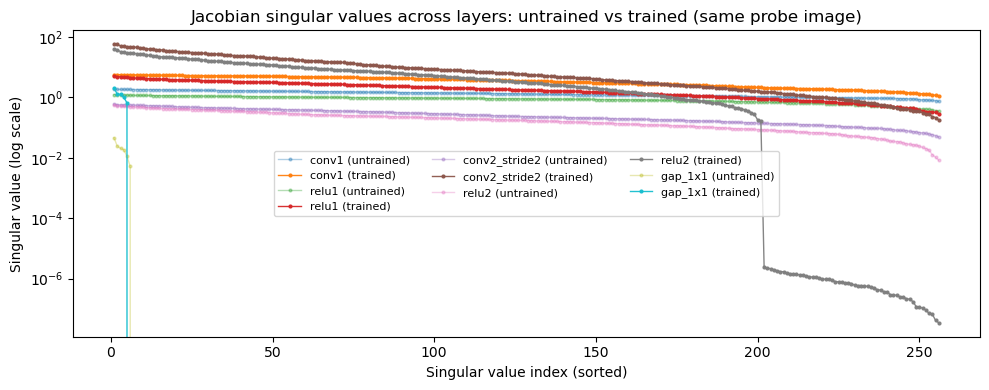


Condition numbers (approx):
          conv1 | kappa_untrained=2.5 | kappa_trained=4.98
          relu1 | kappa_untrained=3.49 | kappa_trained=18
  conv2_stride2 | kappa_untrained=12.3 | kappa_trained=325
          relu2 | kappa_untrained=67 | kappa_trained=1.16e+09
        gap_1x1 | kappa_untrained=inf | kappa_trained=inf


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# =========================
# Config (edit these)
# =========================
TRAIN_ROOT = "../../datasets/imagenette2/train"
VAL_ROOT = "../../datasets/imagenette2/val"

IMG_SIZE = 16              # keep 16 so Jacobians are feasible
BATCH_SIZE = 256
EPOCHS = 100
LR = 1e-2
WEIGHT_DECAY = 1e-4
MAX_STEPS_PER_EPOCH = None # set None for full epoch
PICK_INDEX = 0             # which val image to use for Jacobian spectra
SV_THRESHOLD = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
np.random.seed(0)

# =========================
# Model: same feature stack, add classifier head
# =========================
class TinyCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 3, stride=1, padding=1)
        self.relu1 = nn.ReLU(inplace=False)
        self.conv2 = nn.Conv2d(6, 8, 3, stride=2, padding=1)
        self.relu2 = nn.ReLU(inplace=False)
        self.gap = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(8, num_classes)

    def forward_with_acts(self, x):
        acts = {}
        a1 = self.conv1(x); acts["conv1"] = a1
        r1 = self.relu1(a1); acts["relu1"] = r1
        a2 = self.conv2(r1); acts["conv2_stride2"] = a2
        r2 = self.relu2(a2); acts["relu2"] = r2
        g  = self.gap(r2);  acts["gap_1x1"] = g
        return acts

    def forward(self, x):
        acts = self.forward_with_acts(x)
        z = acts["gap_1x1"].view(x.size(0), -1)  # [B,8]
        logits = self.fc(z)
        return logits

# =========================
# Data
# =========================
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(1),
    transforms.ToTensor(),
])

train_ds = ImageFolder(TRAIN_ROOT, transform=transform)
val_ds   = ImageFolder(VAL_ROOT, transform=transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

num_classes = len(train_ds.classes)
assert num_classes == 10, f"Expected Imagenette2 to have 10 classes, got {num_classes}"

# Pick the Jacobian probe image (from val)
x_probe, y_probe = val_ds[PICK_INDEX]
class_name = val_ds.classes[y_probe]
x_probe = x_probe.unsqueeze(0).to(device).requires_grad_(True)

print("Device:", device)
print("Probe val index:", PICK_INDEX, "| class:", class_name)
print("Probe input shape:", tuple(x_probe.shape))

plt.figure(figsize=(2.5,2.5))
plt.imshow(x_probe.detach().cpu().squeeze(), cmap="gray")
plt.title("Probe input (16x16)")
plt.axis("off")
plt.show()

# =========================
# Jacobian singular values
# =========================
def flatten_act(t):
    return t.reshape(-1)

@torch.no_grad()
def eval_acc(model, loader, max_batches=50):
    model.eval()
    correct = 0
    total = 0
    for bi, (xb, yb) in enumerate(loader):
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model(xb)
        pred = logits.argmax(dim=1)
        correct += (pred == yb).sum().item()
        total += yb.numel()
        if max_batches is not None and (bi + 1) >= max_batches:
            break
    return correct / max(total, 1)

def compute_svals_for_layer(model, x, layer_name):
    def layer_fn(x_in):
        acts = model.forward_with_acts(x_in)
        return flatten_act(acts[layer_name])
    J = torch.autograd.functional.jacobian(layer_fn, x, vectorize=True)
    J = J.reshape(J.shape[0], -1)
    svals = torch.linalg.svdvals(J)
    return svals, J.shape

def summarize_svals(svals, tau=1e-3):
    s = svals.detach().cpu().numpy()
    return {
        "count": int(s.size),
        "eff_rank": int(np.sum(s > tau)),
        "sigma_max": float(s.max()) if s.size else 0.0,
        "sigma_min": float(s.min()) if s.size else 0.0,
    }

layer_order = ["conv1", "relu1", "conv2_stride2", "relu2", "gap_1x1"]

def collect_layer_spectra(model, x):
    model.eval()
    spectra = {}
    shapes = {}
    stats = {}
    for name in layer_order:
        svals, shape = compute_svals_for_layer(model, x, name)
        spectra[name] = svals.detach().cpu()
        shapes[name] = shape
        stats[name] = summarize_svals(svals, SV_THRESHOLD)
    return spectra, shapes, stats

# =========================
# 1) Untrained spectra
# =========================
model = TinyCNN(num_classes=num_classes).to(device)
model.eval()

untrained_spectra, untrained_shapes, untrained_stats = collect_layer_spectra(model, x_probe)

print("\nUNTRAINED layer-wise Jacobian stats:")
for name in layer_order:
    st = untrained_stats[name]
    print(f"{name:>15} | J shape={untrained_shapes[name]} | svs={st['count']} | eff_rank={st['eff_rank']} | "
          f"smax={st['sigma_max']:.4g} | smin={st['sigma_min']:.4g}")

# =========================
# 2) Train
# =========================
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

print("\nTraining...")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    steps = 0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        steps += 1
        if MAX_STEPS_PER_EPOCH is not None and steps >= MAX_STEPS_PER_EPOCH:
            break

    train_loss = running_loss / max(steps, 1)
    val_acc = eval_acc(model, val_loader, max_batches=50)
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | train_loss={train_loss:.4f} | val_acc@50batches={val_acc:.3f}")

# =========================
# 3) Trained spectra
# =========================
# IMPORTANT: re-enable grads on probe tensor after training steps
x_probe = x_probe.detach().requires_grad_(True)

trained_spectra, trained_shapes, trained_stats = collect_layer_spectra(model, x_probe)

print("\nTRAINED layer-wise Jacobian stats:")
for name in layer_order:
    st = trained_stats[name]
    print(f"{name:>15} | J shape={trained_shapes[name]} | svs={st['count']} | eff_rank={st['eff_rank']} | "
          f"smax={st['sigma_max']:.4g} | smin={st['sigma_min']:.4g}")

# =========================
# 4) Plot: untrained vs trained
# =========================
plt.figure(figsize=(10,4))
for name in layer_order:
    s0 = np.sort(untrained_spectra[name].numpy())[::-1]
    s1 = np.sort(trained_spectra[name].numpy())[::-1]
    # plot as two curves per layer, with light styling via alpha (no custom colors)
    plt.plot(range(1, len(s0)+1), s0, marker='o', markersize=2, linewidth=1, alpha=0.35, label=f"{name} (untrained)")
    plt.plot(range(1, len(s1)+1), s1, marker='o', markersize=2, linewidth=1, alpha=0.95, label=f"{name} (trained)")

plt.yscale("log")
plt.xlabel("Singular value index (sorted)")
plt.ylabel("Singular value (log scale)")
plt.title("Jacobian singular values across layers: untrained vs trained (same probe image)")
plt.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

# =========================
# 5) Optional: condition numbers summary
# =========================
def cond_from_stats(st):
    if st["sigma_min"] <= 0:
        return np.inf
    return st["sigma_max"] / st["sigma_min"]

print("\nCondition numbers (approx):")
for name in layer_order:
    k0 = cond_from_stats(untrained_stats[name])
    k1 = cond_from_stats(trained_stats[name])
    print(f"{name:>15} | kappa_untrained={k0:.3g} | kappa_trained={k1:.3g}")


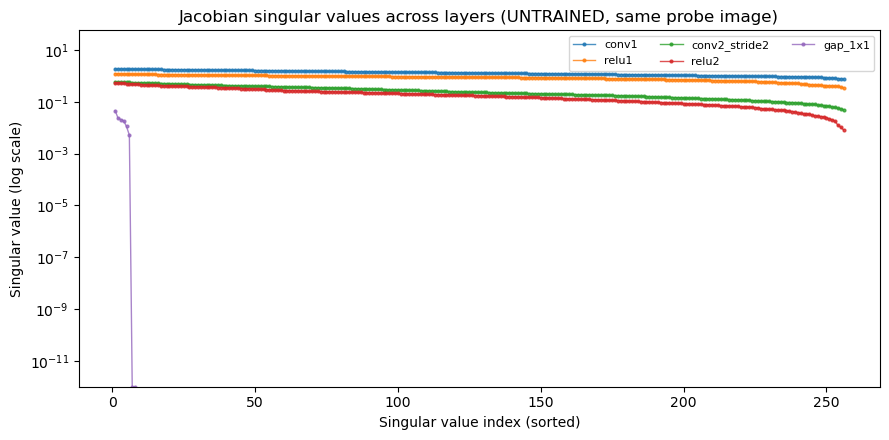

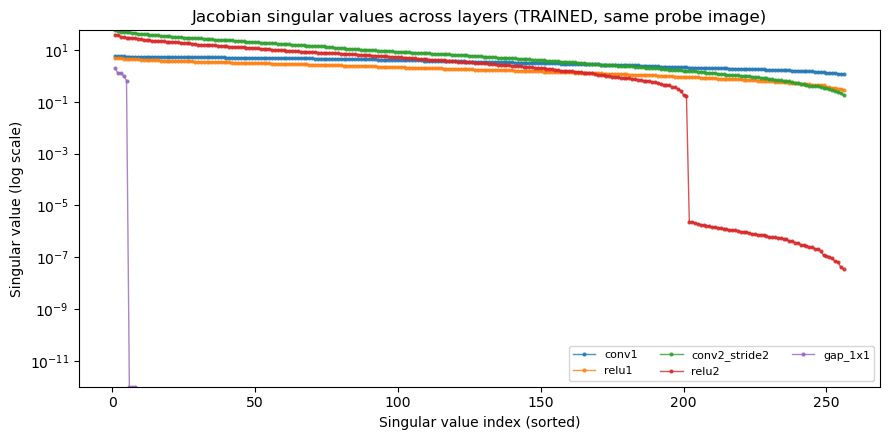

In [17]:
# =========================
# 4) Plot: TWO separate plots (untrained only, trained only)
#     + save to figs/
# =========================
import os
os.makedirs("figs", exist_ok=True)

def sorted_svals_cpu(svals_tensor):
    s = svals_tensor.detach().cpu().numpy()
    s = np.sort(s)[::-1]
    return s

# Compute shared y-limits so the two plots are visually comparable
EPS = 1e-12  # for log scale (handles exact zeros from GAP)
all_vals = []
for name in layer_order:
    all_vals.append(np.maximum(sorted_svals_cpu(untrained_spectra[name]), EPS))
    all_vals.append(np.maximum(sorted_svals_cpu(trained_spectra[name]), EPS))
all_vals = np.concatenate(all_vals)
ymin = float(all_vals.min())
ymax = float(all_vals.max())

def plot_layer_spectra(spectra_dict, title, out_pdf):
    plt.figure(figsize=(9, 4.5))
    for name in layer_order:
        s = np.maximum(sorted_svals_cpu(spectra_dict[name]), EPS)
        plt.plot(
            np.arange(1, len(s) + 1),
            s,
            marker="o",
            markersize=2,
            linewidth=1,
            alpha=0.8,
            label=name,
        )
    plt.yscale("log")
    plt.ylim(ymin, ymax)
    plt.xlabel("Singular value index (sorted)")
    plt.ylabel("Singular value (log scale)")
    plt.title(title)
    plt.legend(ncol=3, fontsize=8)
    plt.tight_layout()
    plt.savefig(out_pdf, bbox_inches="tight")
    plt.show()

plot_layer_spectra(
    untrained_spectra,
    "Jacobian singular values across layers (UNTRAINED, same probe image)",
    "figs/jacobian_svals_untrained.pdf",
)

plot_layer_spectra(
    trained_spectra,
    "Jacobian singular values across layers (TRAINED, same probe image)",
    "figs/jacobian_svals_trained.pdf",
)


Device: cuda
Probe class: n01440764
Input shape: (1, 3, 224, 224)


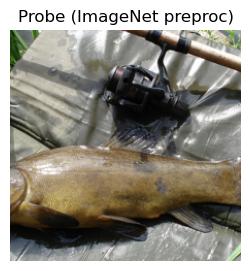

Top-5 predicted class indices: [  0 758 389 391 395]
Top-5 probs: [9.875e-01 1.030e-02 1.100e-03 9.000e-04 1.000e-04]
eig 01: lambda ≈ 9.3247e+01, sigma ≈ 9.6565e+00
eig 02: lambda ≈ 5.4503e+01, sigma ≈ 7.3826e+00
eig 03: lambda ≈ 3.7173e+01, sigma ≈ 6.0970e+00
eig 04: lambda ≈ 3.4029e+01, sigma ≈ 5.8334e+00
eig 05: lambda ≈ 3.0612e+01, sigma ≈ 5.5328e+00
eig 06: lambda ≈ 2.8293e+01, sigma ≈ 5.3191e+00
eig 07: lambda ≈ 2.6858e+01, sigma ≈ 5.1825e+00
eig 08: lambda ≈ 2.4279e+01, sigma ≈ 4.9274e+00
eig 09: lambda ≈ 1.9641e+01, sigma ≈ 4.4319e+00
eig 10: lambda ≈ 2.1911e+01, sigma ≈ 4.6809e+00
eig 11: lambda ≈ 1.9690e+01, sigma ≈ 4.4374e+00
eig 12: lambda ≈ 1.7599e+01, sigma ≈ 4.1951e+00


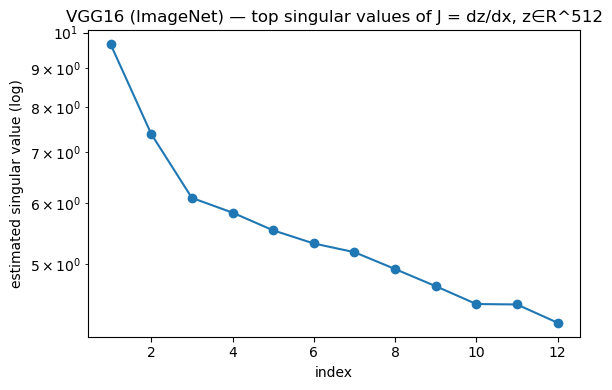

Top singular values: [9.656466 7.382644 6.096956 5.833414 5.532821 5.319076 5.182513 4.927365
 4.680884 4.437384 4.431865 4.195144]


In [10]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import vgg16, VGG16_Weights

# =========================
# Config
# =========================
VAL_ROOT = "../../datasets/imagenette2/val"
PICK_INDEX = 0

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TOP_K = 12                 # how many singular values to estimate
POWER_ITERS = 25           # iterations per singular value
ORTHO_EPS = 1e-10

torch.manual_seed(0)
np.random.seed(0)

print("Device:", DEVICE)

# =========================
# Load VGG16 (pretrained ImageNet) + preprocessing
# =========================
weights = VGG16_Weights.IMAGENET1K_V1
model = vgg16(weights=weights).to(DEVICE).eval()

# ImageNet preprocessing from weights (Resize->CenterCrop->ToTensor->Normalize)
preprocess = weights.transforms()

# Imagenette val dataset, but using ImageNet preprocessing
ds = ImageFolder(VAL_ROOT, transform=preprocess)

x, y = ds[PICK_INDEX]
x = x.unsqueeze(0).to(DEVICE)  # [1,3,224,224]
y_name = ds.classes[y]

print("Probe class:", y_name)
print("Input shape:", tuple(x.shape))

# ImageNet normalization constants
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406], device=DEVICE).view(1,3,1,1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225], device=DEVICE).view(1,3,1,1)

x_disp = (x * IMAGENET_STD + IMAGENET_MEAN).clamp(0, 1)
x_disp = x_disp.detach().cpu().squeeze().permute(1,2,0).numpy()

plt.figure(figsize=(3,3))
plt.imshow(x_disp)
plt.title("Probe (ImageNet preproc)")
plt.axis("off")
plt.show()

# =========================
# Define representation z(x) in R^512
# Use VGG conv features -> global average pool -> 512-d vector
# =========================
@torch.no_grad()
def vgg_pred_topk(x_in, k=5):
    logits = model(x_in)
    probs = logits.softmax(dim=1)
    vals, idx = probs.topk(k, dim=1)
    return vals[0].detach().cpu().numpy(), idx[0].detach().cpu().numpy()

vals, idx = vgg_pred_topk(x, k=5)
print("Top-5 predicted class indices:", idx)
print("Top-5 probs:", np.round(vals, 4))

def z_of_x(x_in):
    # VGG16 features: [B,512,7,7]
    f = model.features(x_in)
    # global average pool to [B,512,1,1] then flatten -> [512]
    z = f.mean(dim=(2,3)).squeeze(0)
    return z  # shape [512]

# =========================
# Implicit A(u) = (J J^T) u using VJP then JVP
# where J = dz/dx at x
# =========================
def JJt_matvec(x_base, u):
    """
    x_base: tensor [1,3,224,224] (no grad required)
    u:      tensor [512]
    returns: (J J^T) u  in R^512
    """
    # VJP: v = J^T u  (shape like x)
    x_var = x_base.detach().requires_grad_(True)
    z = z_of_x(x_var)                 # [512]
    # scalar = <z, u>
    scalar = (z * u).sum()
    v = torch.autograd.grad(scalar, x_var, retain_graph=False, create_graph=False)[0]  # [1,3,224,224]

    # JVP: w = J v
    # Use autograd.functional.jvp to avoid forming J.
    # Need a function returning z(x) with correct shape.
    def fun(inp):
        return z_of_x(inp)

    # jvp expects the tangent to match input structure
    _, w = torch.autograd.functional.jvp(fun, (x_var.detach(),), (v.detach(),), create_graph=False, strict=True)
    return w.detach()  # [512]

# =========================
# Power iteration in output space to get top eigenpairs of A = JJ^T
# Singular values = sqrt(eigenvalues)
# =========================
def top_singular_values_J(x_base, k=10, iters=20):
    m = z_of_x(x_base).numel()  # 512
    Q = []      # found eigenvectors in R^m
    evals = []  # eigenvalues of JJ^T

    for j in range(k):
        u = torch.randn(m, device=x_base.device)
        u = u / (u.norm() + ORTHO_EPS)

        # deflate against previous Q
        if Q:
            for q in Q:
                u = u - (u @ q) * q
            u = u / (u.norm() + ORTHO_EPS)

        for _ in range(iters):
            Au = JJt_matvec(x_base, u)
            # deflate each iteration too (stabilizes)
            if Q:
                for q in Q:
                    Au = Au - (Au @ q) * q
            u = Au / (Au.norm() + ORTHO_EPS)

        Au = JJt_matvec(x_base, u)
        lam = float((u @ Au).item())
        evals.append(max(lam, 0.0))
        Q.append(u.detach())

        print(f"eig {j+1:02d}: lambda ≈ {lam:.4e}, sigma ≈ {np.sqrt(max(lam,0.0)):.4e}")

    svals = np.sqrt(np.array(evals))
    svals = np.sort(svals)[::-1]
    return svals

svals = top_singular_values_J(x, k=TOP_K, iters=POWER_ITERS)

plt.figure(figsize=(6,4))
plt.plot(range(1, len(svals)+1), svals, marker='o')
plt.yscale("log")
plt.xlabel("index")
plt.ylabel("estimated singular value (log)")
plt.title("VGG16 (ImageNet) — top singular values of J = dz/dx, z∈R^512")
plt.tight_layout()
plt.show()

print("Top singular values:", np.round(svals, 6))


Device: cuda
Probe val index: 0 | folder label: n01440764
Input shape: (1, 3, 224, 224)


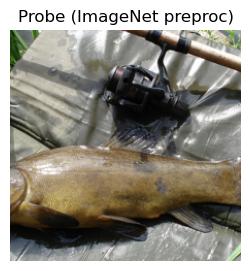

Top-5 predicted class indices: [  0 758 389 391 395]
Top-5 probs: [9.875e-01 1.030e-02 1.100e-03 9.000e-04 1.000e-04]

=== pool1 (C=64) | cut=5 | embedding dim m=64 ===
Top sigmas: [0.1513 0.1298 0.1203 0.0881 0.081  0.0724 0.065  0.0606 0.06   0.0542
 0.0522 0.0496]

=== pool3 (C=256) | cut=17 | embedding dim m=256 ===
Top sigmas: [3.4403 2.4889 2.4502 2.2609 2.2054 2.0744 2.0309 1.9321 1.9145 1.8767
 1.8272 1.8061]

=== pool5 (C=512) | cut=31 | embedding dim m=512 ===
Top sigmas: [9.6564 7.3826 6.0983 5.8326 5.5721 5.3303 5.1282 4.9296 4.7234 4.4515
 4.3868 4.2097]


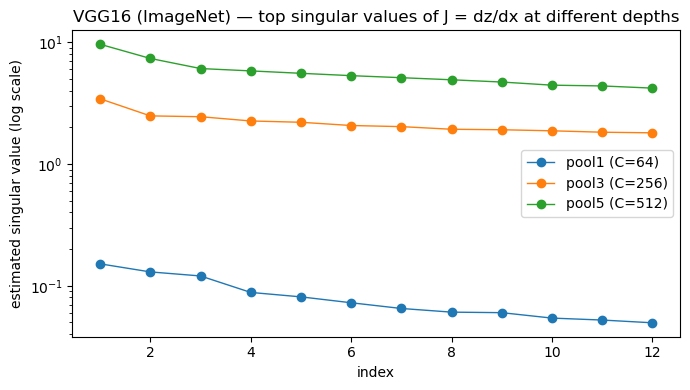


Conditioning proxy from top-k (sigma_1 / sigma_k):
  pool1 (C=64): 3.05
 pool3 (C=256): 1.9
 pool5 (C=512): 2.29


In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder
from torchvision.models import vgg16, VGG16_Weights

# =========================
# Config
# =========================
VAL_ROOT = "../../datasets/imagenette2/val"
PICK_INDEX = 0
TOP_K = 12
POWER_ITERS = 20

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
np.random.seed(0)

# ImageNet normalization constants (stable across torchvision versions)
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406], device=DEVICE).view(1,3,1,1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225], device=DEVICE).view(1,3,1,1)

print("Device:", DEVICE)

# =========================
# Load pretrained VGG16 + preprocessing
# =========================
weights = VGG16_Weights.IMAGENET1K_V1
model = vgg16(weights=weights).to(DEVICE).eval()
preprocess = weights.transforms()

ds = ImageFolder(VAL_ROOT, transform=preprocess)
x, y = ds[PICK_INDEX]
x = x.unsqueeze(0).to(DEVICE)
print("Probe val index:", PICK_INDEX, "| folder label:", ds.classes[y])
print("Input shape:", tuple(x.shape))

# show image (denormalized)
x_disp = (x * IMAGENET_STD + IMAGENET_MEAN).clamp(0, 1).detach().cpu().squeeze().permute(1,2,0).numpy()
plt.figure(figsize=(3,3))
plt.imshow(x_disp)
plt.title("Probe (ImageNet preproc)")
plt.axis("off")
plt.show()

# quick top-5 prediction from full VGG head (not the embedding)
with torch.no_grad():
    logits = model(x)
    probs = logits.softmax(dim=1)
    vals, idx = probs.topk(5, dim=1)
print("Top-5 predicted class indices:", idx[0].cpu().numpy())
print("Top-5 probs:", np.round(vals[0].cpu().numpy(), 4))

# =========================
# Choose a good depth mix (after pooling layers)
# VGG16 features indices:
#   pool1 ends at idx 4 -> slice [:5]
#   pool3 ends at idx 16 -> slice [:17]
#   pool5 ends at idx 30 -> slice [:31]
# =========================
CUTS = [
    ("pool1 (C=64)",  5),
    ("pool3 (C=256)", 17),
    ("pool5 (C=512)", 31),
]

# =========================
# Build embedding z(x) = GAP(features[:cut](x)) in R^C
# =========================
def make_z_of_x(cut):
    feats = model.features[:cut]
    def z_of_x(x_in):
        f = feats(x_in)          # [1,C,H,W]
        z = f.mean(dim=(2,3)).squeeze(0)  # [C]
        return z
    return z_of_x

# =========================
# Implicit matvec for A(u) = (J J^T) u, where J = dz/dx at x
# Uses: v = J^T u via VJP, then w = J v via JVP
# =========================
def JJt_matvec(x_base, u, z_of_x):
    x_var = x_base.detach().requires_grad_(True)
    z = z_of_x(x_var)                   # [C]
    scalar = (z * u).sum()
    v = torch.autograd.grad(scalar, x_var, retain_graph=False, create_graph=False)[0]  # [1,3,224,224]

    def fun(inp):
        return z_of_x(inp)

    _, w = torch.autograd.functional.jvp(fun, (x_var.detach(),), (v.detach(),), create_graph=False, strict=True)
    return w.detach()  # [C]

# =========================
# Block power iteration (subspace iteration) for top-k eigs of A = JJ^T
# Singular values = sqrt(eigs)
# =========================
def top_singular_values_block(x_base, z_of_x, k=12, iters=20, eps=1e-10):
    m = z_of_x(x_base).numel()
    k = min(k, m)

    Q = torch.randn(m, k, device=x_base.device)
    Q, _ = torch.linalg.qr(Q)  # orthonormal columns

    for _ in range(iters):
        Z_cols = []
        for j in range(k):
            Z_cols.append(JJt_matvec(x_base, Q[:, j], z_of_x))
        Z = torch.stack(Z_cols, dim=1)  # [m,k]
        Q, _ = torch.linalg.qr(Z)

    # Rayleigh-Ritz: B = Q^T A Q
    Z_cols = []
    for j in range(k):
        Z_cols.append(JJt_matvec(x_base, Q[:, j], z_of_x))
    Z = torch.stack(Z_cols, dim=1)      # [m,k]
    B = (Q.T @ Z).detach().cpu().numpy()  # [k,k]

    evals, _ = np.linalg.eigh(B)        # ascending
    evals = np.maximum(evals, 0.0)[::-1]
    svals = np.sqrt(evals)
    return svals

# =========================
# Run for each cut + plot
# =========================
all_svals = {}
for name, cut in CUTS:
    z_of_x = make_z_of_x(cut)
    with torch.no_grad():
        m = z_of_x(x).numel()
    print(f"\n=== {name} | cut={cut} | embedding dim m={m} ===")
    svals = top_singular_values_block(x, z_of_x, k=TOP_K, iters=POWER_ITERS)
    all_svals[name] = svals
    print("Top sigmas:", np.round(svals, 4))

plt.figure(figsize=(7,4))
for name, svals in all_svals.items():
    plt.plot(range(1, len(svals)+1), svals, marker='o', linewidth=1, label=name)
plt.yscale("log")
plt.xlabel("index")
plt.ylabel("estimated singular value (log scale)")
plt.title("VGG16 (ImageNet) — top singular values of J = dz/dx at different depths")
plt.legend()
plt.tight_layout()
plt.savefig("vgg16_jacobian_svals_by_depth.pdf", bbox_inches="tight")
plt.show()

# quick conditioning proxy from top-k only (NOT the true condition number)
print("\nConditioning proxy from top-k (sigma_1 / sigma_k):")
for name, svals in all_svals.items():
    if len(svals) >= 2:
        print(f"{name:>14}: {svals[0]/svals[-1]:.3g}")


Device: cuda
Val size: 3925
Probe A index=0 class=n01440764
Probe B index=1 class=n01440764 (same)
Probe C index=387 class=n02102040 (different)


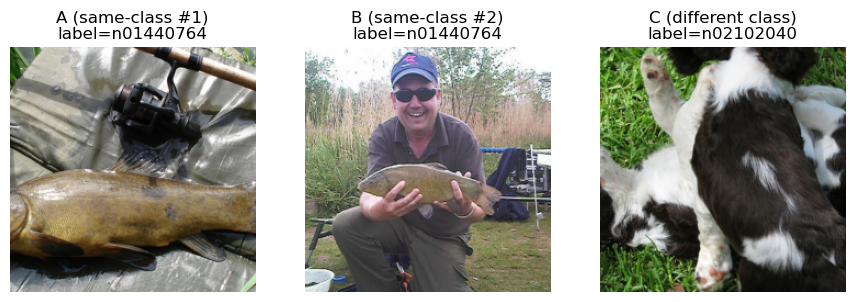

A (same-class #1): label=n01440764
  top-5 idx: [  0 758 389 391 395]
  top-5 p  : [9.875e-01 1.030e-02 1.100e-03 9.000e-04 1.000e-04]
B (same-class #2): label=n01440764
  top-5 idx: [  0 389 395 758 391]
  top-5 p  : [9.997e-01 3.000e-04 0.000e+00 0.000e+00 0.000e+00]
C (different class): label=n02102040
  top-5 idx: [217 219 215 218 232]
  top-5 p  : [0.9495 0.0304 0.0057 0.0021 0.0019]

=== A (same-class #1) | pool1 (C=64) (cut=5) ===
Top sigmas: [0.1513 0.1298 0.1203 0.0881 0.081  0.0724 0.065  0.0606 0.06   0.0542
 0.0522 0.0496]

=== B (same-class #2) | pool1 (C=64) (cut=5) ===
Top sigmas: [0.1479 0.1285 0.1226 0.0892 0.0748 0.0702 0.0638 0.0594 0.0583 0.0527
 0.0505 0.0484]

=== C (different class) | pool1 (C=64) (cut=5) ===
Top sigmas: [0.1546 0.126  0.1219 0.0873 0.0866 0.0725 0.0688 0.0641 0.0623 0.057
 0.0532 0.0513]

=== A (same-class #1) | pool3 (C=256) (cut=17) ===
Top sigmas: [3.4403 2.489  2.4502 2.2608 2.2054 2.0744 2.0308 1.9321 1.9138 1.8778
 1.8305 1.7568]

=== B (s

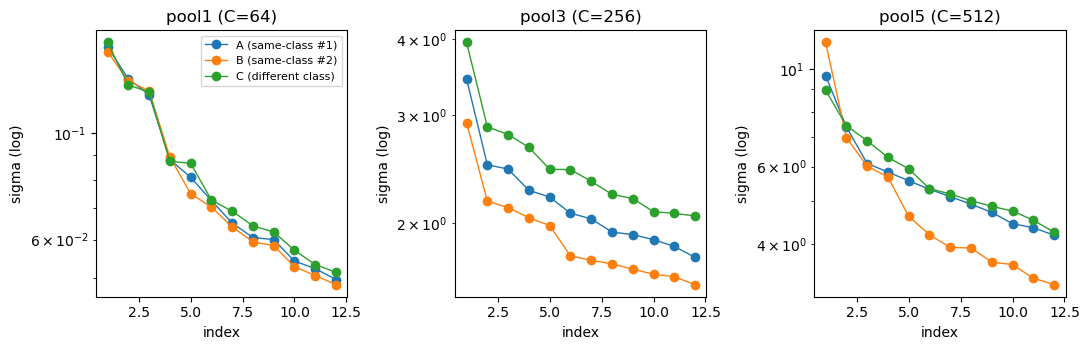


Conditioning proxy (sigma_1 / sigma_k) from top-k only:

pool1 (C=64):
   A (same-class #1): 3.05
   B (same-class #2): 3.06
  C (different class): 3.01

pool3 (C=256):
   A (same-class #1): 1.96
   B (same-class #2): 1.84
  C (different class): 1.92

pool5 (C=512):
   A (same-class #1): 2.3
   B (same-class #2): 3.55
  C (different class): 2.1

Relative spectrum distance  ||s-t||/||s||  (top-k only):

pool1 (C=64):
   A vs B (same class): 0.0283
   A vs C (diff class): 0.0335
   B vs C (diff class): 0.0573

pool3 (C=256):
   A vs B (same class): 0.1286
   A vs C (diff class): 0.1489
   B vs C (diff class): 0.3165

pool5 (C=512):
   A vs B (same class): 0.1714
   A vs C (diff class): 0.0630
   B vs C (diff class): 0.2271


In [16]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder
from torchvision.models import vgg16, VGG16_Weights

# =========================
# Config
# =========================
VAL_ROOT = "../../datasets/imagenette2/val"

# Pick 3 probes:
#   A = a fixed index
#   B = another sample with SAME folder label as A
#   C = a sample with DIFFERENT folder label
PICK_A = 0
MAX_SEARCH = 5000          # how far to scan to find B and C

TOP_K = 12
POWER_ITERS = 20
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
np.random.seed(0)

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406], device=DEVICE).view(1,3,1,1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225], device=DEVICE).view(1,3,1,1)

print("Device:", DEVICE)

# =========================
# Load pretrained VGG16 + preprocessing
# =========================
weights = VGG16_Weights.IMAGENET1K_V1
model = vgg16(weights=weights).to(DEVICE).eval()
preprocess = weights.transforms()

ds = ImageFolder(VAL_ROOT, transform=preprocess)
N = len(ds)
print("Val size:", N)

# =========================
# Find B (same class) and C (different class)
# =========================
xA, yA = ds[PICK_A]
yA = int(yA)

pick_B = None
pick_C = None

for i in range(min(N, MAX_SEARCH)):
    if i == PICK_A:
        continue
    _, yi = ds[i]
    yi = int(yi)
    if pick_B is None and yi == yA:
        pick_B = i
    if pick_C is None and yi != yA:
        pick_C = i
    if pick_B is not None and pick_C is not None:
        break

if pick_B is None or pick_C is None:
    raise RuntimeError("Could not find both a same-class and different-class example. Increase MAX_SEARCH.")

print(f"Probe A index={PICK_A} class={ds.classes[yA]}")
print(f"Probe B index={pick_B} class={ds.classes[yA]} (same)")
print(f"Probe C index={pick_C} class={ds.classes[ds[pick_C][1]]} (different)")

def load_probe(idx):
    x, y = ds[idx]
    return x.unsqueeze(0).to(DEVICE), int(y)

xA, yA = load_probe(PICK_A)
xB, yB = load_probe(pick_B)
xC, yC = load_probe(pick_C)

PROBES = [
    ("A (same-class #1)", xA, yA),
    ("B (same-class #2)", xB, yB),
    ("C (different class)", xC, yC),
]

# =========================
# Helper: show probes + top-5 preds
# =========================
@torch.no_grad()
def top5(x):
    logits = model(x)
    probs = logits.softmax(dim=1)
    vals, idx = probs.topk(5, dim=1)
    return idx[0].cpu().numpy(), vals[0].cpu().numpy()

plt.figure(figsize=(9,3))
for j,(name,x,y) in enumerate(PROBES, start=1):
    x_disp = (x * IMAGENET_STD + IMAGENET_MEAN).clamp(0, 1).detach().cpu().squeeze().permute(1,2,0).numpy()
    plt.subplot(1,3,j)
    plt.imshow(x_disp)
    plt.title(f"{name}\nlabel={ds.classes[y]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

for name,x,y in PROBES:
    idx, vals = top5(x)
    print(f"{name}: label={ds.classes[y]}")
    print("  top-5 idx:", idx)
    print("  top-5 p  :", np.round(vals, 4))

# =========================
# Depth mix (after pooling layers)
# =========================
CUTS = [
    ("pool1 (C=64)",  5),
    ("pool3 (C=256)", 17),
    ("pool5 (C=512)", 31),
]

def make_z_of_x(cut):
    feats = model.features[:cut]
    def z_of_x(x_in):
        f = feats(x_in)                 # [1,C,H,W]
        z = f.mean(dim=(2,3)).squeeze(0)  # [C]
        return z
    return z_of_x

def JJt_matvec(x_base, u, z_of_x):
    x_var = x_base.detach().requires_grad_(True)
    z = z_of_x(x_var)             # [C]
    scalar = (z * u).sum()
    v = torch.autograd.grad(scalar, x_var, retain_graph=False, create_graph=False)[0]  # [1,3,224,224]

    def fun(inp):
        return z_of_x(inp)

    _, w = torch.autograd.functional.jvp(fun, (x_var.detach(),), (v.detach(),), create_graph=False, strict=True)
    return w.detach()  # [C]

def top_singular_values_block(x_base, z_of_x, k=12, iters=20):
    m = z_of_x(x_base).numel()
    k = min(k, m)

    Q = torch.randn(m, k, device=x_base.device)
    Q, _ = torch.linalg.qr(Q)

    for _ in range(iters):
        Z_cols = [JJt_matvec(x_base, Q[:, j], z_of_x) for j in range(k)]
        Z = torch.stack(Z_cols, dim=1)  # [m,k]
        Q, _ = torch.linalg.qr(Z)

    # Rayleigh-Ritz on subspace
    Z_cols = [JJt_matvec(x_base, Q[:, j], z_of_x) for j in range(k)]
    Z = torch.stack(Z_cols, dim=1)
    B = (Q.T @ Z).detach().cpu().numpy()
    evals, _ = np.linalg.eigh(B)
    evals = np.maximum(evals, 0.0)[::-1]
    return np.sqrt(evals)

# =========================
# Run: spectra for each probe and each depth
# =========================
results = {}  # (probe_name, cut_name) -> svals
for cut_name, cut in CUTS:
    z_of_x = make_z_of_x(cut)
    for probe_name, x, y in PROBES:
        print(f"\n=== {probe_name} | {cut_name} (cut={cut}) ===")
        svals = top_singular_values_block(x, z_of_x, k=TOP_K, iters=POWER_ITERS)
        results[(probe_name, cut_name)] = svals
        print("Top sigmas:", np.round(svals, 4))

# =========================
# Plot: one panel per depth, curves = probes
# =========================
plt.figure(figsize=(11,3.6))
for p,(cut_name,_) in enumerate(CUTS, start=1):
    plt.subplot(1,3,p)
    for probe_name, _, _ in PROBES:
        svals = results[(probe_name, cut_name)]
        plt.plot(range(1, len(svals)+1), svals, marker='o', linewidth=1, label=probe_name)
    plt.yscale("log")
    plt.xlabel("index")
    plt.ylabel("sigma (log)")
    plt.title(cut_name)
    if p == 1:
        plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("vgg16_jacobian_svals_by_probe_and_depth.pdf", bbox_inches="tight")
plt.show()

# =========================
# Simple summary: top-k conditioning proxy per probe & depth
# =========================
print("\nConditioning proxy (sigma_1 / sigma_k) from top-k only:")
for cut_name,_ in CUTS:
    print(f"\n{cut_name}:")
    for probe_name, _, _ in PROBES:
        svals = results[(probe_name, cut_name)]
        print(f"  {probe_name:>18}: {float(svals[0]/svals[-1]):.3g}")

# =========================
# Quantify differences between spectra (same-class vs different-class)
# =========================
def rel_spec_dist(s, t, eps=1e-12):
    s = np.asarray(s)
    t = np.asarray(t)
    return float(np.linalg.norm(s - t) / (np.linalg.norm(s) + eps))

pairs = [
    ("A vs B (same class)", "A (same-class #1)", "B (same-class #2)"),
    ("A vs C (diff class)", "A (same-class #1)", "C (different class)"),
    ("B vs C (diff class)", "B (same-class #2)", "C (different class)"),
]

print("\nRelative spectrum distance  ||s-t||/||s||  (top-k only):")
for cut_name, _ in CUTS:
    print(f"\n{cut_name}:")
    for label, p1, p2 in pairs:
        d = rel_spec_dist(results[(p1, cut_name)], results[(p2, cut_name)])
        print(f"  {label:>20}: {d:.4f}")
